In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
DATA_PATH = "D:\\HealthForecastAI\\ml\\data\\raw\\diabetic_data.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# identify treatment related columns

In [3]:
print("Total columns:", len(df.columns))

for col in df.columns:
    print(col)

Total columns: 50
encounter_id
patient_nbr
race
gender
age
weight
admission_type_id
discharge_disposition_id
admission_source_id
time_in_hospital
payer_code
medical_specialty
num_lab_procedures
num_procedures
num_medications
number_outpatient
number_emergency
number_inpatient
diag_1
diag_2
diag_3
number_diagnoses
max_glu_serum
A1Cresult
metformin
repaglinide
nateglinide
chlorpropamide
glimepiride
acetohexamide
glipizide
glyburide
tolbutamide
pioglitazone
rosiglitazone
acarbose
miglitol
troglitazone
tolazamide
examide
citoglipton
insulin
glyburide-metformin
glipizide-metformin
glimepiride-pioglitazone
metformin-rosiglitazone
metformin-pioglitazone
change
diabetesMed
readmitted


# Treatment exposure summary 

In [4]:
medication_columns = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",
]

available_medications = [
    col for col in medication_columns if col in df.columns
]

print("Medication columns found:", len(available_medications))
print(available_medications)

Medication columns found: 23
['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


# Medical exposure count

In [5]:
medication_exposure = {}

for medication in available_medications:
    medication_exposure[medication] = (
        ~df[medication].isin(["No", ""])
    ).sum()

medication_exposure_df = (
    pd.Series(medication_exposure)
    .sort_values(ascending=False)
    .reset_index()
)

medication_exposure_df.columns = ["medication", "patient_count"]

medication_exposure_df

,medication,patient_count
0,insulin,54383
1,metformin,19988
2,glipizide,12686
3,glyburide,10650
4,pioglitazone,7328
5,rosiglitazone,6365
6,glimepiride,5191
7,repaglinide,1539
8,glyburide-metformin,706
9,nateglinide,703


see the distribution of column

In [6]:
df["readmitted"].value_counts(dropna=False)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [7]:
df["readmitted"].value_counts(normalize=True, dropna=False) * 100

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

# medication wise outcome analysis

In [8]:
# Create medication-wise outcome analysis

outcome_analysis = []

for medication in available_medications:
    # Patients who received/used the medication
    medication_mask = ~df[medication].isin(["No", ""])

    medication_df = df.loc[medication_mask].copy()

    total_patients = len(medication_df)

    if total_patients == 0:
        continue

    no_readmission = (medication_df["readmitted"] == "NO").sum()
    readmitted_after_30 = (medication_df["readmitted"] == ">30").sum()
    readmitted_within_30 = (medication_df["readmitted"] == "<30").sum()

    outcome_analysis.append({
        "medication": medication,
        "total_patients": total_patients,
        "no_readmission": no_readmission,
        "readmitted_30_plus": readmitted_after_30,
        "readmitted_under_30": readmitted_within_30,
        "no_readmission_rate": no_readmission / total_patients * 100,
        "readmission_30_plus_rate": readmitted_after_30 / total_patients * 100,
        "readmission_under_30_rate": readmitted_within_30 / total_patients * 100,
    })

medication_outcome_df = pd.DataFrame(outcome_analysis)

medication_outcome_df = medication_outcome_df.sort_values(
    "total_patients",
    ascending=False
)

medication_outcome_df

,medication,total_patients,no_readmission,readmitted_30_plus,readmitted_under_30,no_readmission_rate,readmission_30_plus_rate,readmission_under_30_rate
15,insulin,54383,28186,19596,6601,51.828696,36.033319,12.137984
0,metformin,19988,11343,6706,1939,56.749049,33.550130,9.700820
6,glipizide,12686,6504,4730,1452,51.269116,37.285196,11.445688
7,glyburide,10650,5800,3718,1132,54.460094,34.910798,10.629108
9,pioglitazone,7328,3797,2757,774,51.814956,37.622817,10.562227
10,rosiglitazone,6365,3291,2409,665,51.704635,37.847604,10.447761
4,glimepiride,5191,2754,1907,530,53.053362,36.736660,10.209979
1,repaglinide,1539,694,640,205,45.094217,41.585445,13.320338
16,glyburide-metformin,706,370,258,78,52.407932,36.543909,11.048159
2,nateglinide,703,361,262,80,51.351351,37.268848,11.379801


# effectiveness metric
No-readmission rate = percentage of patients receiving a medication who were not readmitted.

In [9]:
medication_effectiveness = medication_outcome_df[
    [
        "medication",
        "total_patients",
        "no_readmission_rate",
        "readmission_30_plus_rate",
        "readmission_under_30_rate",
    ]
].copy()

medication_effectiveness = medication_effectiveness.sort_values(
    "no_readmission_rate",
    ascending=False
)

medication_effectiveness

,medication,total_patients,no_readmission_rate,readmission_30_plus_rate,readmission_under_30_rate
19,metformin-rosiglitazone,2,100.000000,0.000000,0.000000
20,metformin-pioglitazone,1,100.000000,0.000000,0.000000
14,tolazamide,39,66.666667,25.641026,7.692308
8,tolbutamide,23,65.217391,30.434783,4.347826
0,metformin,19988,56.749049,33.550130,9.700820
3,chlorpropamide,86,54.651163,39.534884,5.813953
7,glyburide,10650,54.460094,34.910798,10.629108
4,glimepiride,5191,53.053362,36.736660,10.209979
16,glyburide-metformin,706,52.407932,36.543909,11.048159
15,insulin,54383,51.828696,36.033319,12.137984


# We used no-readmission rate as an observational outcome indicator to compare treatment outcomes across medications.”

In [10]:
reliable_medication_analysis = medication_effectiveness[
    medication_effectiveness["total_patients"] >= 100
].copy()

reliable_medication_analysis

,medication,total_patients,no_readmission_rate,readmission_30_plus_rate,readmission_under_30_rate
0,metformin,19988,56.749049,33.550130,9.700820
7,glyburide,10650,54.460094,34.910798,10.629108
4,glimepiride,5191,53.053362,36.736660,10.209979
16,glyburide-metformin,706,52.407932,36.543909,11.048159
15,insulin,54383,51.828696,36.033319,12.137984
9,pioglitazone,7328,51.814956,37.622817,10.562227
10,rosiglitazone,6365,51.704635,37.847604,10.447761
2,nateglinide,703,51.351351,37.268848,11.379801
6,glipizide,12686,51.269116,37.285196,11.445688
1,repaglinide,1539,45.094217,41.585445,13.320338


# visualization

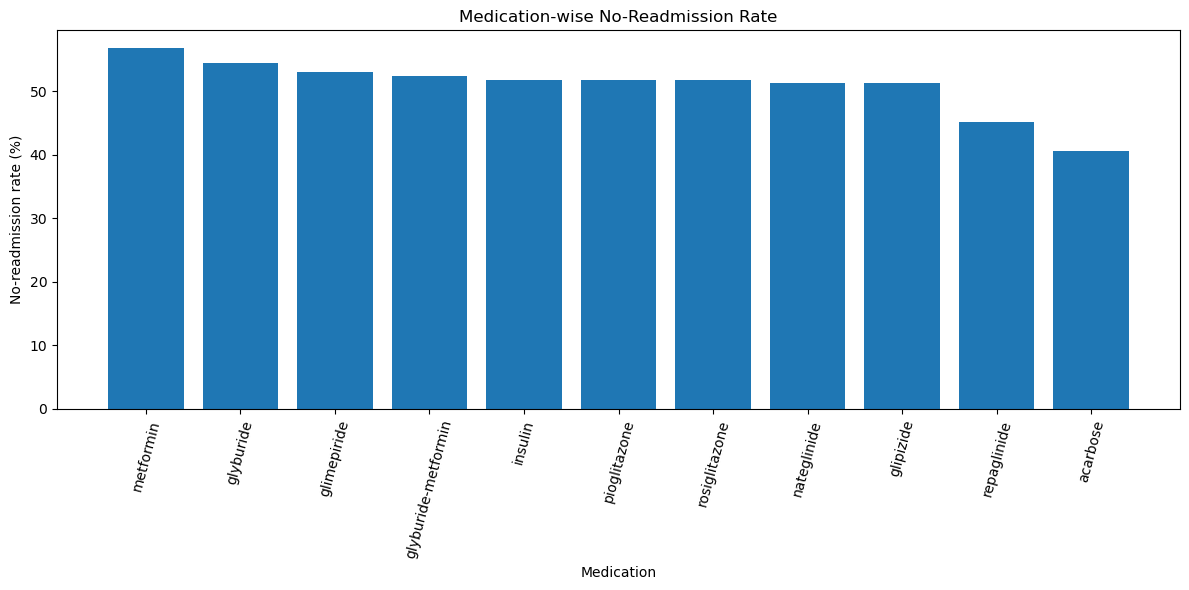

In [11]:
plt.figure(figsize=(12, 6))

plt.bar(
    reliable_medication_analysis["medication"],
    reliable_medication_analysis["no_readmission_rate"]
)

plt.xlabel("Medication")
plt.ylabel("No-readmission rate (%)")
plt.title("Medication-wise No-Readmission Rate")
plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

In [12]:
reliable_medication_analysis = medication_effectiveness[
    medication_effectiveness["total_patients"] >= 100
].copy()

reliable_medication_analysis

,medication,total_patients,no_readmission_rate,readmission_30_plus_rate,readmission_under_30_rate
0,metformin,19988,56.749049,33.550130,9.700820
7,glyburide,10650,54.460094,34.910798,10.629108
4,glimepiride,5191,53.053362,36.736660,10.209979
16,glyburide-metformin,706,52.407932,36.543909,11.048159
15,insulin,54383,51.828696,36.033319,12.137984
9,pioglitazone,7328,51.814956,37.622817,10.562227
10,rosiglitazone,6365,51.704635,37.847604,10.447761
2,nateglinide,703,51.351351,37.268848,11.379801
6,glipizide,12686,51.269116,37.285196,11.445688
1,repaglinide,1539,45.094217,41.585445,13.320338


In [13]:
reliable_medication_analysis["outcome_rate"] = (
    reliable_medication_analysis["no_readmission_rate"]
)

reliable_medication_analysis[
    [
        "medication",
        "total_patients",
        "no_readmission_rate",
        "readmission_30_plus_rate",
        "readmission_under_30_rate",
        "outcome_rate",
    ]
]

,medication,total_patients,no_readmission_rate,readmission_30_plus_rate,readmission_under_30_rate,outcome_rate
0,metformin,19988,56.749049,33.550130,9.700820,56.749049
7,glyburide,10650,54.460094,34.910798,10.629108,54.460094
4,glimepiride,5191,53.053362,36.736660,10.209979,53.053362
16,glyburide-metformin,706,52.407932,36.543909,11.048159,52.407932
15,insulin,54383,51.828696,36.033319,12.137984,51.828696
9,pioglitazone,7328,51.814956,37.622817,10.562227,51.814956
10,rosiglitazone,6365,51.704635,37.847604,10.447761,51.704635
2,nateglinide,703,51.351351,37.268848,11.379801,51.351351
6,glipizide,12686,51.269116,37.285196,11.445688,51.269116
1,repaglinide,1539,45.094217,41.585445,13.320338,45.094217


# Treatment comparison chart

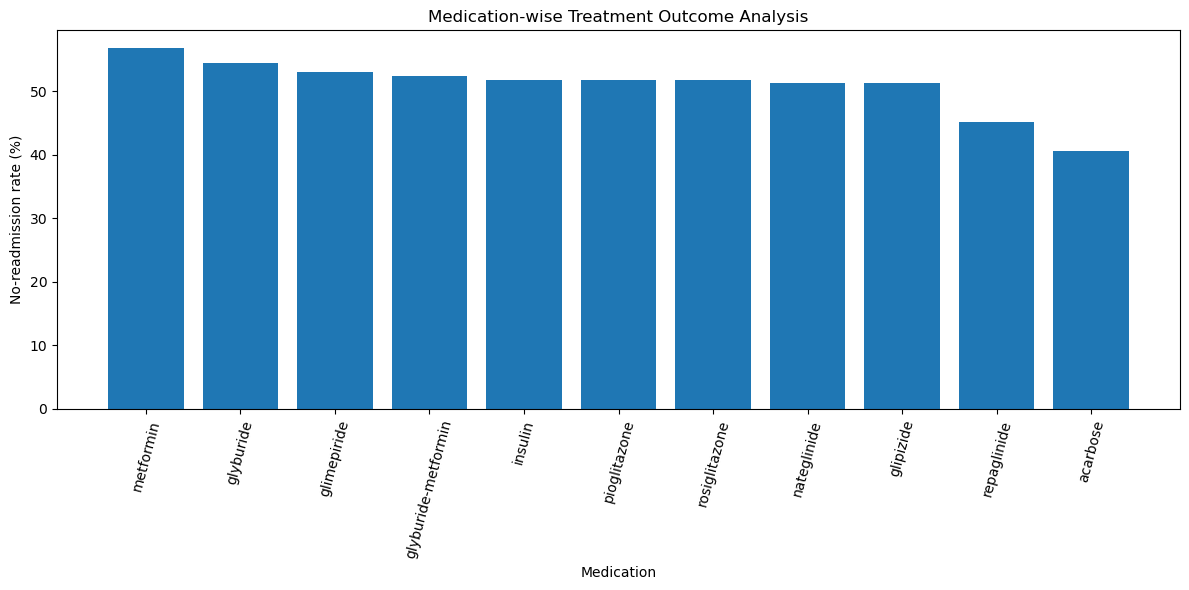

In [14]:
plt.figure(figsize=(12, 6))

plt.bar(
    reliable_medication_analysis["medication"],
    reliable_medication_analysis["outcome_rate"]
)

plt.xlabel("Medication")
plt.ylabel("No-readmission rate (%)")
plt.title("Medication-wise Treatment Outcome Analysis")
plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

# Treatment effectiveness score

In [15]:
overall_no_readmission_rate = (
    (df["readmitted"] == "NO").mean() * 100
)

reliable_medication_analysis["effectiveness_gap"] = (
    reliable_medication_analysis["no_readmission_rate"]
    - overall_no_readmission_rate
)

print(
    f"Overall no-readmission rate: "
    f"{overall_no_readmission_rate:.2f}%"
)

reliable_medication_analysis[
    [
        "medication",
        "total_patients",
        "no_readmission_rate",
        "effectiveness_gap",
    ]
].sort_values(
    "effectiveness_gap",
    ascending=False
)

Overall no-readmission rate: 53.91%


,medication,total_patients,no_readmission_rate,effectiveness_gap
0,metformin,19988,56.749049,2.837134
7,glyburide,10650,54.460094,0.548178
4,glimepiride,5191,53.053362,-0.858554
16,glyburide-metformin,706,52.407932,-1.503984
15,insulin,54383,51.828696,-2.083219
9,pioglitazone,7328,51.814956,-2.096959
10,rosiglitazone,6365,51.704635,-2.207281
2,nateglinide,703,51.351351,-2.560564
6,glipizide,12686,51.269116,-2.642800
1,repaglinide,1539,45.094217,-8.817699


# outcome distribution chart

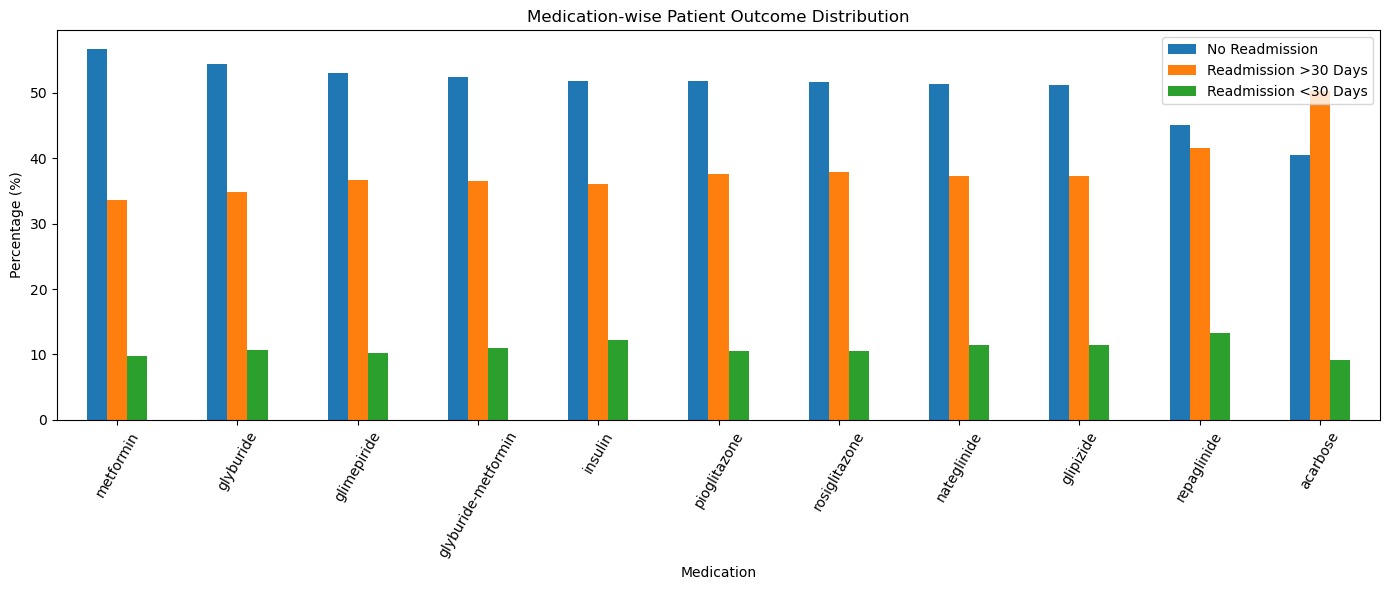

In [16]:
plot_df = reliable_medication_analysis.sort_values(
    "no_readmission_rate",
    ascending=False
)

plot_df = plot_df.set_index("medication")[
    [
        "no_readmission_rate",
        "readmission_30_plus_rate",
        "readmission_under_30_rate",
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.xlabel("Medication")
plt.ylabel("Percentage (%)")
plt.title("Medication-wise Patient Outcome Distribution")
plt.xticks(rotation=60)
plt.legend(
    [
        "No Readmission",
        "Readmission >30 Days",
        "Readmission <30 Days",
    ]
)
plt.tight_layout()
plt.show()

# Medical treatment change analysis

In [18]:
print(df["change"].value_counts(dropna=False))
print()
print(df["diabetesMed"].value_counts(dropna=False))

change
No    54755
Ch    47011
Name: count, dtype: int64

diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64


# change vs outcome

In [19]:
change_outcome = pd.crosstab(
    df["change"],
    df["readmitted"],
    normalize="index"
) * 100

change_outcome

readmitted,<30,>30,NO
change,,,
Ch,11.822765,36.740337,51.436898
No,10.590814,33.372295,56.036892


# clean visualization

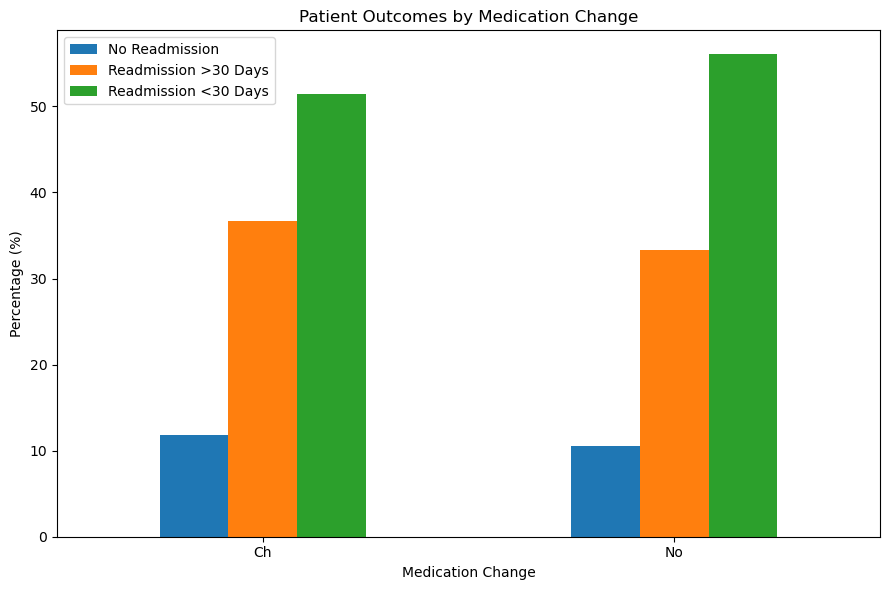

In [20]:
ax = change_outcome.plot(
    kind="bar",
    figsize=(9, 6)
)

ax.set_xlabel("Medication Change")
ax.set_ylabel("Percentage (%)")
ax.set_title("Patient Outcomes by Medication Change")
ax.legend([
    "No Readmission",
    "Readmission >30 Days",
    "Readmission <30 Days",
])

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# final treatment effectiveness summary

In [21]:
treatment_summary = reliable_medication_analysis[
    [
        "medication",
        "total_patients",
        "no_readmission_rate",
        "readmission_30_plus_rate",
        "readmission_under_30_rate",
        "effectiveness_gap",
    ]
].copy()

treatment_summary.columns = [
    "Treatment",
    "Patients",
    "No_Readmission_Rate",
    "Readmission_After_30_Rate",
    "Readmission_Under_30_Rate",
    "Baseline_Gap",
]

treatment_summary

,Treatment,Patients,No_Readmission_Rate,Readmission_After_30_Rate,Readmission_Under_30_Rate,Baseline_Gap
0,metformin,19988,56.749049,33.550130,9.700820,2.837134
7,glyburide,10650,54.460094,34.910798,10.629108,0.548178
4,glimepiride,5191,53.053362,36.736660,10.209979,-0.858554
16,glyburide-metformin,706,52.407932,36.543909,11.048159,-1.503984
15,insulin,54383,51.828696,36.033319,12.137984,-2.083219
9,pioglitazone,7328,51.814956,37.622817,10.562227,-2.096959
10,rosiglitazone,6365,51.704635,37.847604,10.447761,-2.207281
2,nateglinide,703,51.351351,37.268848,11.379801,-2.560564
6,glipizide,12686,51.269116,37.285196,11.445688,-2.642800
1,repaglinide,1539,45.094217,41.585445,13.320338,-8.817699
